# CS235 Fall 2025 Course Project

Name: Sharmeen Kazi, Vineesha Avasarala

Student ID: 862620019, 862620893

## Introduction
In this project, a number of data mining techniques that we cover in this class will be implemented and applied to a real-world imbalanced
dataset.

**Dataset:** Wisconsin Breast Cancer Diagnostic dataset from the UCI data repository: https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic

## Setup

1. Create new python environment for the project

- This is not necessary on Google Colab but a good practice on your local machine

2. Install the required packages

## Imports

In [10]:
!pip install ucimlrepo

In [11]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

import itertools, collections
import numpy as np
import pandas as pd

from ucimlrepo import fetch_ucirepo

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split

from sklearn.metrics import silhouette_score

## Load Data

In [12]:
# Fetch dataset
#breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17)

from sklearn.datasets import load_breast_cancer
data = load_breast_cancer(as_frame=True)
X = data.data          # features
y = pd.DataFrame({'Diagnosis': data.target})    # labels

# Data (as pandas dataframes)
#X = breast_cancer_wisconsin_diagnostic.data.features
#y = breast_cancer_wisconsin_diagnostic.data.targets

# Metadata
#print(breast_cancer_wisconsin_diagnostic.metadata)

## Exploratory Data Analysis (EDA)

### Pairwise correlation between features

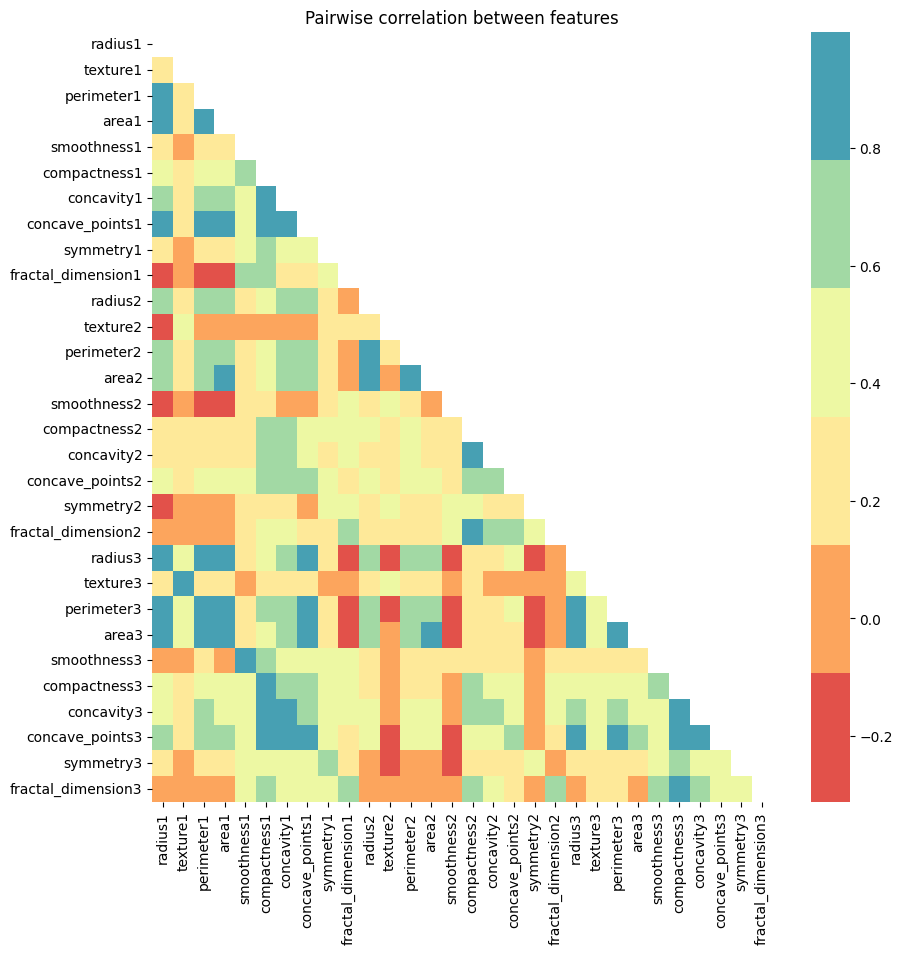

In [ ]:
correlation = X.corr()

fig, ax = plt.subplots(1,1, figsize=(10,10))
sns.heatmap(correlation, annot=False, mask=np.triu(correlation),
            cmap=sns.color_palette("Spectral"))
ax.set_title("Pairwise correlation between features")
plt.show()

### Class Counts

In [ ]:
print(collections.Counter(y['Diagnosis']))

Counter({'B': 357, 'M': 212})


### Class-wise features distributions

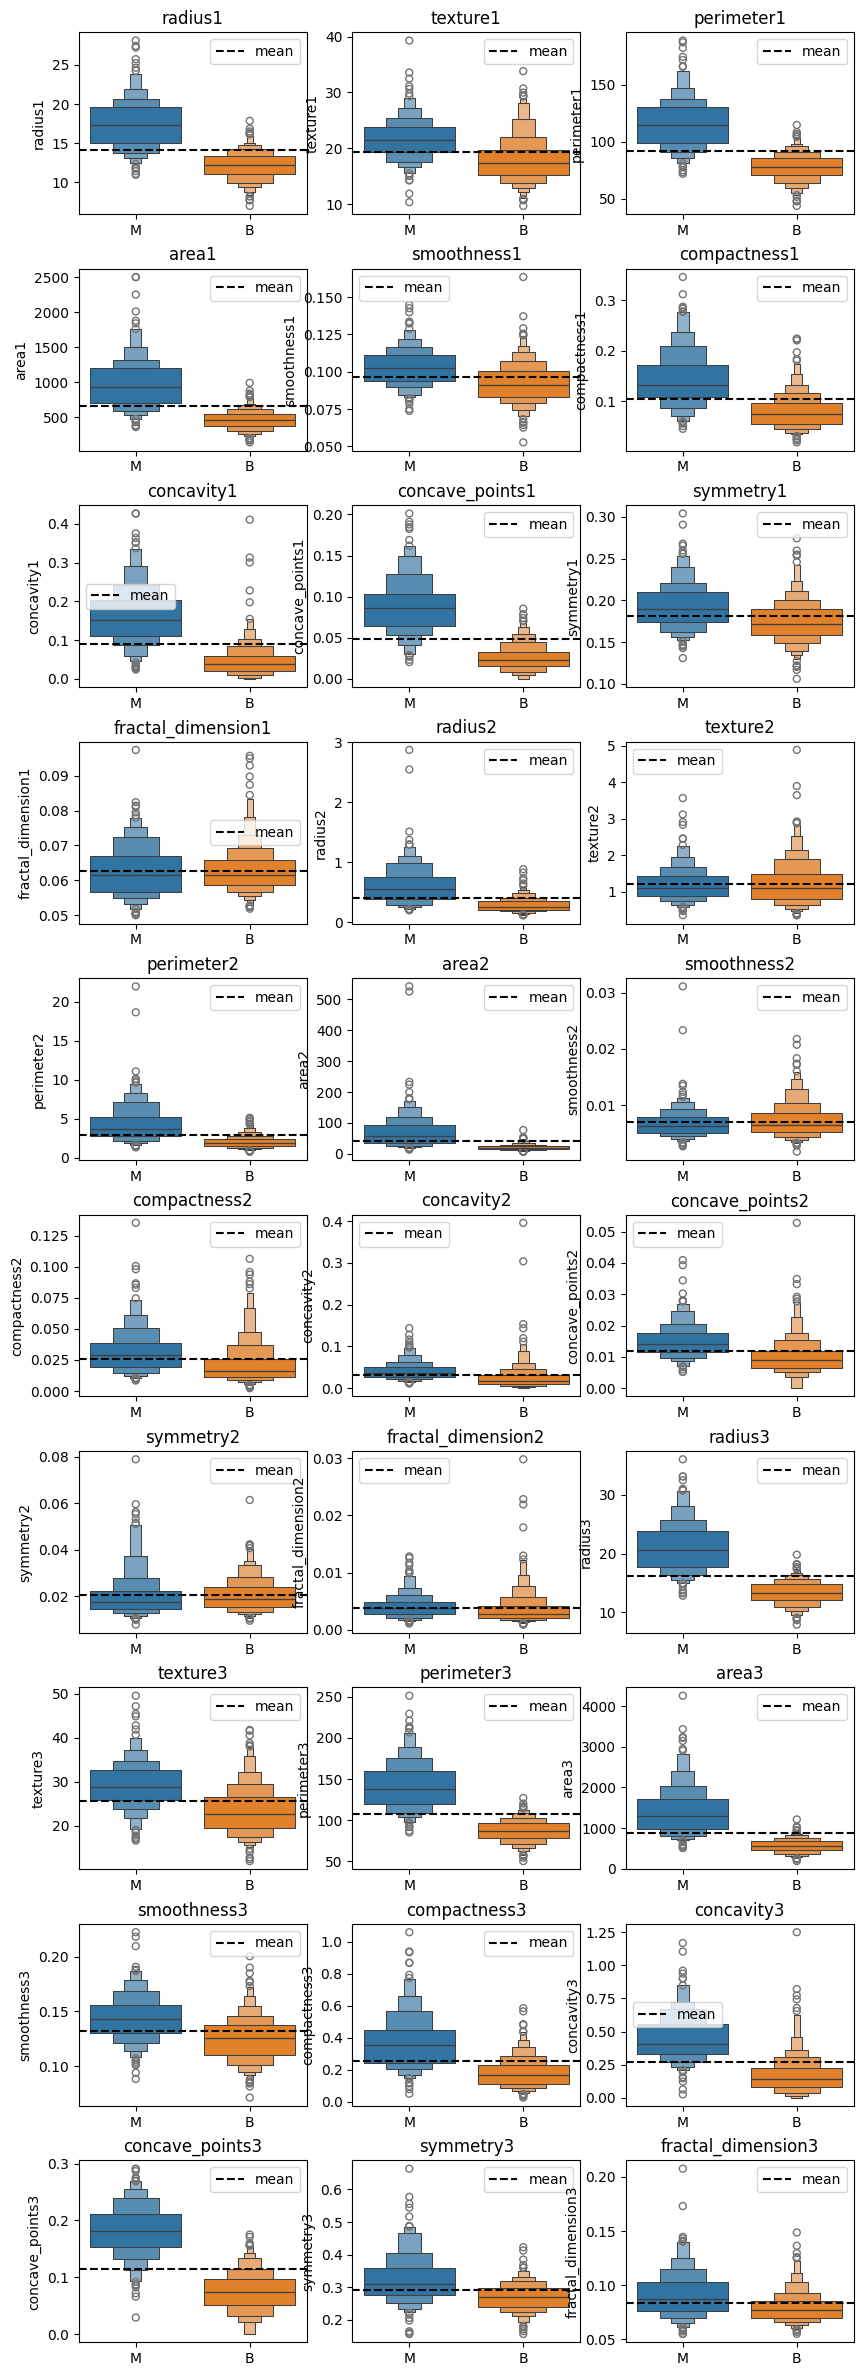

In [ ]:
plt.figure(figsize=(10,30))

for i,j in itertools.zip_longest(list(X.columns), range(len(list(X.columns)))):
  plt.subplot(10,3,j+1)
  sns.boxenplot(x=y['Diagnosis'], y=X[i], hue=y['Diagnosis'])
  plt.title(i)
  plt.xlabel('')
  plt.subplots_adjust(hspace=.3)
  plt.axhline(X[i].mean(), linestyle="dashed", color='k', label='mean')
  plt.legend(loc='best')

## Phase 2

Since the implementations involve distance based calculations, we started off by standarding the data to zero mean and unit standard deviation.

In [4]:
# standardising the data
X_scaled = StandardScaler().fit_transform(X)

### 1. K means implementation

We first defined the initialisation functions for vanilla kmeans and kmeans++. Vanilla kmeans uses random co-ordinates to initialise the centroids, within the data's range. Kmeans++ strategically picks points farthest from each other as initial centroids. It is important to note that while kmeans++ initialises the centroids as actual data points, the final centroids will not necessarily be data points.

Next we defined functions to assign labels of points to closest centroid, and to update centroids as mean of assigned cluster points. We also handled empty clusters by reinitialising the centroids.

We defined the fitting function according to Lloyd's algorithm to sequentially assign clusters first, then update centroids and finally check for convergence.

Finally, we defined functions to evaluate the performance of each of the kmeans initialisation methods by running the models 10 times with different values of k and to plot the results. K = 1 is not displayed on the plot since the silhouette score is undefined for k < 2. In the plot, we see a decreasing performance for both initialisation methods, with vanilla kmeans surprisingly performing better than kmeans++. This is likely due to the presence of non-spherical clusters, or just high dimensionality.

In [5]:
# implementing the k means class with random and kmeans++ initialisation
class kmeans:
    def __init__(self, k, init='kmeans++', max_iters=100, tol=1e-4): # setting default to kmeans++
        self.k = k
        self.init = init
        self.max_iters = max_iters
        self.tol = tol
        self.centroids = None
        self.labels = None

    def random_init(self, X):
        n_features = X.shape[1]
        min_vals = X.min(axis=0)
        max_vals = X.max(axis=0)
        centroids = np.random.uniform(min_vals, max_vals, (self.k, n_features)) # choose k random centroids between the min and max co-ords
        return centroids

    def kpp_init(self, X):
        n_samples = X.shape[0]
        centroids = []

        # choose the first centroid randomly
        idx = np.random.randint(n_samples)
        centroids.append(X[idx])

        # choose the remaining k-1 centroids
        for i in range(1, self.k):
            # distances from each point to nearest centroid
            distances = np.array([min([np.linalg.norm(x - c)**2 for c in centroids]) for x in X])

            # choose the next centroid based on probability based on distance
            probabilities = distances / distances.sum()
            next_idx = np.random.choice(n_samples, p=probabilities)
            centroids.append(X[next_idx])

        return np.array(centroids)

    def assign_clusters(self, X):
        # assigning each point to closest centroid
        distances = np.array([[np.linalg.norm(x - c) for c in self.centroids] for x in X])
        return np.argmin(distances, axis=1)

    def update_centroids(self, X, labels):
        # updating centroids as mean of cluster
        new_centroids = []
        for i in range(self.k):
          cluster_points = X[labels == i] # getting points of given cluster
          if len(cluster_points) > 0: # updating centroid if there are non-zero points in the cluster
            new_centroids.append(cluster_points.mean(axis=0))
          else:
            # re-initialising empty clusters
            new_centroids.append(X[np.random.randint(len(X))])
        return np.array(new_centroids)

    def fit(self, X):
        # initialising centroids
        if self.init == 'kmeans++':
            self.centroids = self.kpp_init(X)
        else:
            self.centroids = self.random_init(X)

        # Lloyd's algorithm
        for it in range(self.max_iters):
            # cluster assignment
            self.labels = self.assign_clusters(X)

            # centroid update
            new_centroids = self.update_centroids(X, self.labels)

            # convergence check
            diff = np.linalg.norm(new_centroids - self.centroids)
            self.centroids = new_centroids
            if diff < self.tol:
                break

        return self


In [6]:
# i will now define a function to evaluate the above class with 10 runs and 5 k values
def evaluate_kmeans(X, k_vals, n_runs=10):
    # initialising a dictionary to store results
    results = {
        'random': {'means': [], 'stds': []},
        'kmeans++': {'means': [], 'stds': []}
    }

    for k in k_vals:
        if k < 2: # silhouette score requires at least 2 clusters, so enter nan for k<2
            results['random']['means'].append(np.nan)
            results['random']['stds'].append(0)
            results['kmeans++']['means'].append(np.nan)
            results['kmeans++']['stds'].append(0)
            continue

        random_scores = [] # track vanilla k means silhouette
        kmeanspp_scores = [] # track kmeans++ silhouette

        for run in range(n_runs):
            # vanilla k means
            km = kmeans(k=k, init='random') # initialising a vanilla model
            km.fit(X) # fitting
            score = silhouette_score(X, km.labels) # evaluating silhouette score
            random_scores.append(score) # saving score

            # kmeans++ model
            km_pp = kmeans(k=k, init='kmeans++') # initialising model
            km_pp.fit(X) # fitting
            score_pp = silhouette_score(X, km_pp.labels) # evaluating silhouette score
            kmeanspp_scores.append(score_pp) # saving score

        # saving means and stds of all scores
        results['random']['means'].append(np.mean(random_scores))
        results['random']['stds'].append(np.std(random_scores))
        results['kmeans++']['means'].append(np.mean(kmeanspp_scores))
        results['kmeans++']['stds'].append(np.std(kmeanspp_scores))

    return results

def plot_kmeans_performance(k_vals, results):
    plt.figure(figsize=(10, 6))

    # plot vanilla kmeans performance
    plt.errorbar(k_vals, results['random']['means'], yerr=results['random']['stds'], marker='o', c='r', label='Vanilla K-means')

    # plot k-means++ performance
    plt.errorbar(k_vals, results['kmeans++']['means'], yerr=results['kmeans++']['stds'], marker='x', c='b', label='K-Means++')

    plt.xlabel('K')
    plt.ylabel('Silhouette score')
    plt.title('K-means performance')
    plt.legend()
    plt.grid(alpha=0.5)
    plt.show()


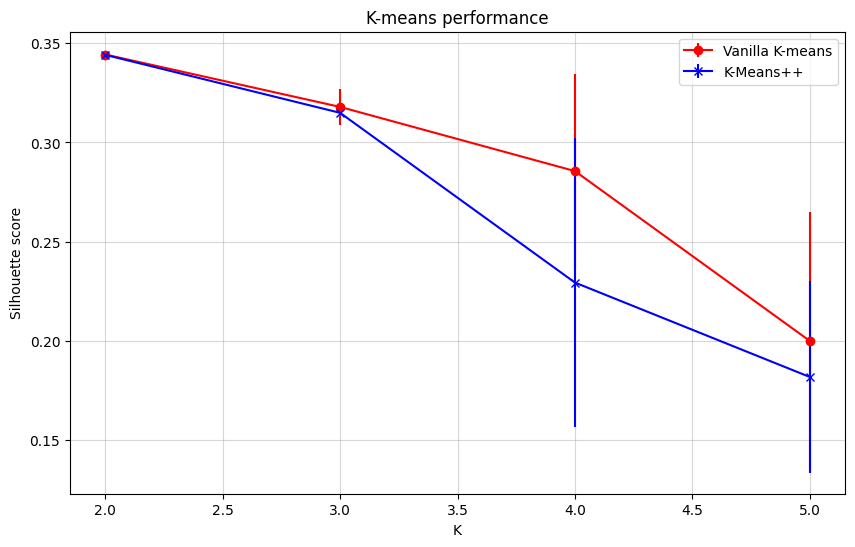

In [ ]:
k_vals = [1,2,3,4,5]
n_runs = 10

# evaluating the two algorithms for k ranging from 2 to 6, with 10 runs for each k
results = evaluate_kmeans(X_scaled, k_vals, n_runs)

# plotting the results
plot_kmeans_performance(k_vals, results)

### 2. DBSCAN implementation

In DBSCAN's definition, we first implemented a helper function to find the neighbouring points within eps radius of a given point.

In the fitting function, we first defined all points as unvisited. Then we iterated through every point in the dataset, checking if it is a core point or not by counting the number of neighbours and comparing with the MinPts threshold. For noise points, we marked its label as -1 and moved on to the next point in the dataset. For core points, we proceeded to initialise a new cluster, and added all its neighbours as candidates for that cluster. Then we visited each neighbour and added it to the cluster if it did not already belong to some other cluster. If it qualified as a core point, then we added its neighbours to the list of candidates too. Once we iterated through all the candidates in the neighbour list, we moved on to checking the next point in the dataset.

Since DBSCAN is mostly deterministic, we evaluated this implementation only once for different values of eps and MinPts each. Upon plotting, we see that the bigger eps radius (5) performs better than the smaller eps (2). The performance worsens upon increasing MinPts. Both of these indicate loosely bound clusters.

In [ ]:
# implementing DBSCAN
class DBSCAN:
    def __init__(self, eps, min_pts):
        self.eps = eps
        self.min_pts = min_pts
        self.labels = None

    def get_neighbours(self, X, point_idx):
        distances = np.linalg.norm(X - X[point_idx], axis=1) # find distances from given point to entire dataset
        neighbours = np.where(distances <= self.eps)[0] # find points within distance eps
        return neighbours

    def fit(self, X):
        n_samples = X.shape[0]
        self.labels = np.full(n_samples, -1)  # assigning all points as unvisited
        cluster_id = 0 # initialising cluster numbers

        for point_idx in range(n_samples):
            # find neighbours
            neighbours = self.get_neighbours(X, point_idx)

            # checking if a given point is a core point
            if len(neighbours) < self.min_pts:
                self.labels[point_idx] = -1  # marking as noise
                continue # proceeding with the next point

            # start a new cluster
            self.labels[point_idx] = cluster_id

            # expand this cluster
            neighbours = list(neighbours)
            i = 0
            while i < len(neighbours): # visit each neighbour
                neighbour_idx = neighbours[i]

                # if noise/unvisited, change it to a border point
                if self.labels[neighbour_idx] == -1:
                    self.labels[neighbour_idx] = cluster_id

                    # find neighbours of current neighbour
                    nb_neighbour = self.get_neighbours(X, neighbour_idx)

                    # if the neighbour is a core point, add its neighbours to the neighbour set
                    if len(nb_neighbour) >= self.min_pts:
                        neighbours.extend(nb_neighbour)

                i += 1 # next point in neighbours list
            cluster_id += 1 # next cluster
        return self


In [ ]:
# evaluation function for DBSCAN
# DBSCAN is almost deterministic so n_runs = 1
def evaluate_dbscan(X, min_pts_vals, eps_vals):
    # initialising results dictionary
    results = {
        eps_vals[0]: {'means': [], 'stds': []},
        eps_vals[1]: {'means': [], 'stds': []}
    }

    for eps in eps_vals:
        for min_pts in min_pts_vals:
            scores = []

            dbscan = DBSCAN(eps=eps, min_pts=min_pts)
            dbscan.fit(X)

            # count clusters (excluding noise points)
            n_clusters = len(set(dbscan.labels)) - (1 if -1 in dbscan.labels else 0)

            # calculate silhouette score on non-noise points
            if n_clusters >= 2: # only if there are 2 or more clusters
                mask = dbscan.labels != -1 # for non-noise points
                if np.sum(mask) > 1:  # need minimum 2 non-noise points
                    score = silhouette_score(X[mask], dbscan.labels[mask])
                    scores.append(score)
                else:
                    scores.append(np.nan)
            else:
                scores.append(np.nan)

            # saving means and stds
            results[eps]['means'].append(np.nanmean(scores) if scores else np.nan)
            results[eps]['stds'].append(np.nanstd(scores) if scores else 0)

    return results

# function to plot DBSCAN performance
def plot_dbscan_performance(min_pts_vals, results):
    plt.figure(figsize=(10, 6))

    markers = ['x', 'o']
    colors = ['b', 'r']
    for idx, (eps, m, c) in enumerate(zip(results.keys(), markers, colors)):
        plt.errorbar(min_pts_vals, results[eps]['means'], yerr=results[eps]['stds'], marker=m, c=c, label=f'Eps = {eps}')

    plt.xlabel('MinPts')
    plt.ylabel('Silhouette score')
    plt.title('DBSCAN performance')
    plt.legend()
    plt.grid(alpha=0.5)
    plt.show()

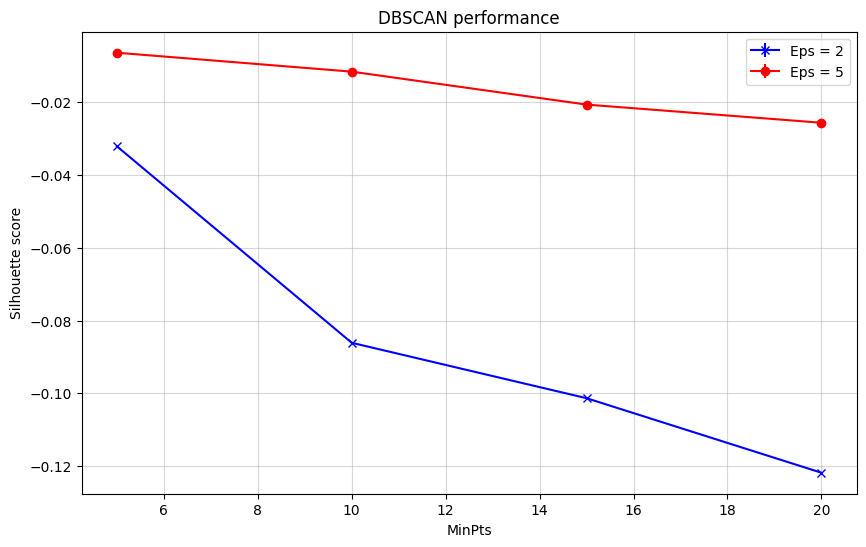

In [ ]:
eps_vals = [2,5]
min_pts_vals = [5,10,15,20]

# evaluating
results = evaluate_dbscan(X_scaled, min_pts_vals, eps_vals)

# plotting the results
plot_dbscan_performance(min_pts_vals, results)


### 3. Graph-based spectral clustering implementation

We first defined a helper gaussian similarity function with the mathematical formal described in the referenced paper, to get the similarity matrix.

In the implementation of the unnormalised spectral clustering function, we first computed the Laplacian with help of the gaussian similarity matrix as previously defined. Upon decomposing the Laplacian into its eigenvectors and eigenvalues, we extracted the top k eigenvectors of the Laplacian. Finally, we performed kmeans++ clustering on these top k eigenvectors with our own implementation of kmeans clustering.

We evaluated this implementation 10 times for different values of k and sigma. Upon plotting, we find that sigma = 10 performs the best, closely followed by sigma = 1, with almost no standard deviation. This indicates stability of the model. Performance seems to follow a decreasing trend, with k = 2 and k = 3 having practically the same performance.

In [ ]:
# defining the gaussian similarity function
def gaussian_similarity(X, sigma):
    # as given in the paper, w_ij = exp(-||xi - xj||^2 / (2 * sigma^2))
    sq_norms = np.sum(X ** 2, axis=1)
    sq_dists = sq_norms[:, None] + sq_norms[None, :] - 2 * (X @ X.T)
    W = np.exp(-sq_dists / (2 * sigma ** 2))
    np.fill_diagonal(W, 0.0)  # no self loops
    return W

# defining the unnormalised spectral clustering function
def spectral_clustering(X, k, sigma):
    W = gaussian_similarity(X, sigma) # gaussian similarity matrix
    D = np.diag(W.sum(axis=1))
    L = D - W # laplacian

    eigvals, eigvecs = np.linalg.eigh(L) # eigen decomposition
    idx = np.argsort(eigvals)
    U = eigvecs[:, idx[:k]] # first k eigenvectors of L

    # kmeans clustering U with our own implementation
    km = kmeans(k=k, init="kmeans++")
    km.fit(U)
    labels = km.labels
    return labels


In [ ]:
# function to evaluate spectral clustering performance
def evaluate_spectral_clustering(X, k_vals, sigma_vals, n_runs=10):
    results = {}

    for sigma in sigma_vals:
        results[sigma] = {'means': [], 'stds': []} # results for current sigma

        for k in k_vals:
            if k < 2: # silhouette score requires at least 2 clusters, so enter nan for k<2
                results[sigma]['means'].append(np.nan)
                results[sigma]['stds'].append(0)
                continue

            scores = []

            for run in range(n_runs):
                labels = spectral_clustering(X, k, sigma) # run spectral clustering with shuffled dataset

                # calculate silhouette score
                n_clusters = len(np.unique(labels))
                if n_clusters >= 2 and n_clusters < len(X): # if there are 2 or more clusters, and not every point is a different cluster
                    score = silhouette_score(X, labels)
                    scores.append(score)
                else:
                    scores.append(np.nan) # for n_clusters < 2

            # saving scores
            results[sigma]['means'].append(np.mean(scores))
            results[sigma]['stds'].append(np.std(scores))

    return results

# and finally, a function to plot the scores for different values of sigma and k
def plot_spectral_performance(k_values, results):
    plt.figure(figsize=(10, 6))

    colours = ['r','b','g']
    markers = ['o', 'x', 's']

    # plot the silhouette scores for each sigma
    for idx, (sigma, color, marker) in enumerate(zip(results.keys(), colours, markers)):
        plt.errorbar(k_values, results[sigma]['means'], yerr=results[sigma]['stds'], marker=marker, c=color, label=f'σ = {sigma}')

    plt.xlabel('K')
    plt.ylabel('Silhouette score')
    plt.title('Spectral clustering performance')
    plt.legend()
    plt.grid(alpha=0.5)
    plt.show()

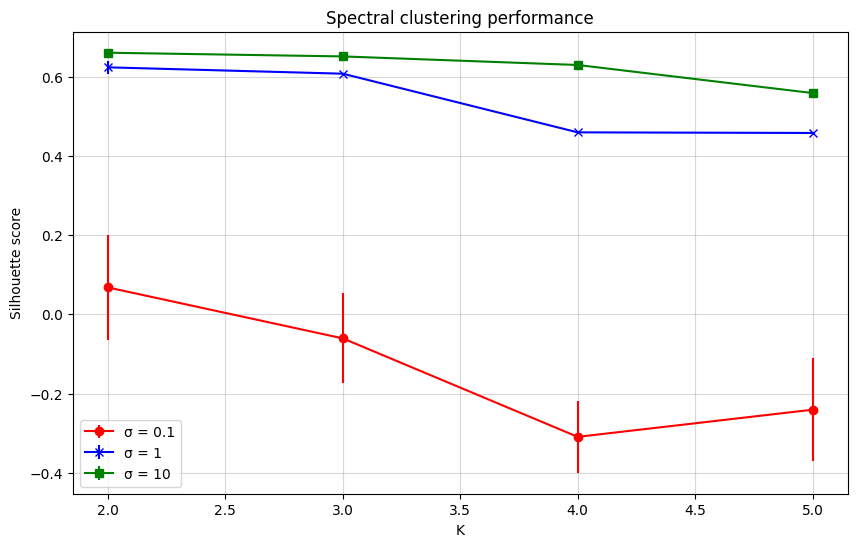

In [ ]:
k_vals = [1,2,3,4,5]
sigma_vals = [0.1,1,10]

# evaluate the implemented spectral clustering
results = evaluate_spectral_clustering(X_scaled, k_vals, sigma_vals, n_runs=10)

# plot performance
plot_spectral_performance(k_vals, results)

### 4. Isolation forest implementation

We started off by implementing a node structure to build the tree with. Then we defined the nromalisation constant c for n >= 2, which is crucial to standardise anomaly scores.

We defined a function to build a tree based on the maximum depth provided. The tree is desgined to pick a random feature and a random threshold to split its nodes on. It returns the child node, unless the split creates an empty partition on one side, in case of which it returns the entire sample.

We defined a function to calculate the length of the path to a leaf from the root node.

Using the above helper functions, we implemented an isolation forest that initialises with 100 trees and 256 sample size by default. It calculates the max depth based on the number of samples, and then builds each tree by sampling without replacement, as done in the original paper. Anomaly scores are assigned to each sample by calculating their average path length from the root node, and then using the formula $s(x) = 2^{-E(h(x))/c(n)}$.

We fit the isolation forest on our original dataset, and then evaluated the kmeans++ performance upon removal of the top 1%, 5%, 10% and 15% anomalies, as well as with the baseline, ie. no anomaly removal. Interestingly, we see a decreasing trend in performance upon removing more and more anomalies, and all the isolation forest methods perform worse than the baseline. This indicates that our data does not have well defined clusters, and hence no distinct anomalies.

In [7]:
# tree implementation
class TreeNode:
    def __init__(self, feature=None, split=None, left=None, right=None, size=None):
        self.feature = feature   # feature index
        self.split = split       # split threshold
        self.left = left         # left child
        self.right = right       # right child
        self.size = size         # leaf size for external nodes

# function for normalization constant c(n)
def c_factor(n):
    if n <= 1:
        return 0.0 # no normalisation for n < 2
    elif n == 2:
        return 1.0
    H = np.log(n - 1) + 0.5772156649  # Euler-Mascheroni constant
    return 2.0 * H - (2.0 * (n - 1) / n)

# function to build a tree
def build_tree(X, current_depth, max_depth, rng):
    n_samples, n_features = X.shape

    if current_depth >= max_depth or n_samples <= 1: # if max_depth reached, or single sample is left, return node
        return TreeNode(size=n_samples)

    q = rng.integers(0, n_features) # choose a random feature
    col = X[:, q]
    min_val, max_val = col.min(), col.max() # feature's extreme values

    if min_val == max_val: # cannot split further
        return TreeNode(size=n_samples)

    p = rng.uniform(min_val, max_val) # choose random threshold between min and max
    left_mask = col < p # split
    right_mask = ~left_mask

    if np.sum(left_mask) == 0 or np.sum(right_mask) == 0: # if either side of the split is empty
       return TreeNode(size=n_samples) # return the whole sample

    #return child node
    return TreeNode(feature=q, split=p,
                    left=build_tree(X[left_mask], current_depth + 1, max_depth, rng),
                    right=build_tree(X[right_mask], current_depth + 1, max_depth, rng)
                    )

# function to calculate length of the path from root to a particular leaf
def path_length(x, node, current_depth=0):
    if node.size is not None: # for external nodes
        return current_depth + c_factor(node.size)

    if x[node.feature] < node.split:
        return path_length(x, node.left, current_depth + 1) # recursively calculate length of child
    else:
        return path_length(x, node.right, current_depth + 1)

# isolation forest implementation
class IsolationForest:
    def __init__(self, sample_size=256, n_trees=100): # initialise with 100 trees and 256 subsample size by default
        self.n_trees = n_trees
        self.sample_size = sample_size
        self.trees = []
        self.c = None

    def fit(self, X):
        rng = np.random.default_rng() # random generator
        n_samples = X.shape[0]
        psi = min(self.sample_size, n_samples)
        self.c = c_factor(psi) # normalisation factor for given sample size
        self.trees = []

        max_depth = np.ceil(np.log2(psi)) # calculate max depth

        for i in range(self.n_trees): # build each tree
            idx = rng.choice(n_samples, size=psi, replace=False) # sampling without replacement
            X_sub = X[idx] # sampled subset
            tree = build_tree(X_sub, current_depth=0, max_depth=max_depth, rng=rng) # tree built on sampled subset
            self.trees.append(tree) # save tree

    # function to calculate anomaly score for each sample
    def anomaly_score(self, X):
        n_samples = X.shape[0]
        avg_path_length = np.zeros(n_samples) # initialise avg path length list for each sample

        for i in range(n_samples):
            x = X[i]
            h_sum = 0.0
            for tree in self.trees:
                h_sum += path_length(x, tree, current_depth=0) # add the height for given sample in every tree
            avg_path_length[i] = h_sum / len(self.trees) # avg path length

        # score: s(x) = 2^{-E(h(x))/c(n)}
        scores = np.power(2.0, -avg_path_length / self.c)
        return scores


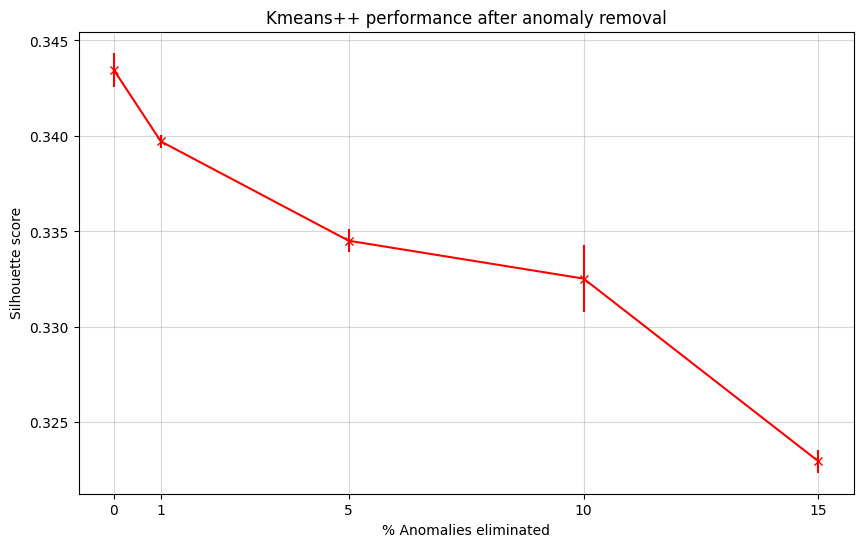

In [9]:
anomaly_percentages = [0.0, 0.01, 0.05, 0.10, 0.15] # % anomalies to test
n_runs = 10

# results dictionary
results = {
    'anomaly_percentage': [],
    'mean_score': [],
    'std_score': []
}

# fitting the isolation forest on original data
forest = IsolationForest(n_trees=100, sample_size=256)
forest.fit(X_scaled)

# getting the anomaly scores for all points
anomaly_scores = forest.anomaly_score(X_scaled)

# evaluating kmeans++ at each anomaly percentage removal
for anomaly_percentage in anomaly_percentages:
    # getting the threshold for this %
    threshold = np.percentile(anomaly_scores, 100 * (1 - anomaly_percentage))

    # eliminating anomalies
    mask = anomaly_scores < threshold
    X_filtered = X_scaled[mask]
    y_filtered = y[mask]

    # running kmeans++ 10 times with k=2
    scores = []
    for run in range(n_runs):
      km = kmeans(k=2, init='kmeans++')
      km.fit(X_filtered)
      score = silhouette_score(X_filtered, km.labels)
      scores.append(score)

    mean_score = np.mean(scores)
    std_score = np.std(scores)

    # saving results
    results['anomaly_percentage'].append(anomaly_percentage*100)
    results['mean_score'].append(mean_score)
    results['std_score'].append(std_score)

# plot results
plt.figure(figsize=(10, 6))
plt.errorbar(results['anomaly_percentage'], results['mean_score'], yerr=results['std_score'], marker='x', c='r')
plt.xlabel('% Anomalies eliminated')
plt.ylabel('Silhouette score')
plt.title('Kmeans++ performance after anomaly removal')
plt.grid(alpha=0.5)
plt.xticks(results['anomaly_percentage'])
plt.show()